# Phase 12 vs Phase 12.5 — composition regime audit

**Author:** Riccardo (with help from Claude)
**Date:** 2026-05-25
**Context:** Federico ran logistic regressions on the Phase 12 composition results
(`composition_scoring_l17_summary.json`, α=4, normalize=False, 36 pairs) and
found that `|cos|` predicts `is_additive` with **in-sample AUC 0.828, permutation p ≈ 0.06**
and the multi-class regime with **in-sample AUC 0.698, p ≈ 0.06**. On the new
Phase 12.5 dataset (`composition_scoring_l17_v2_summary.json`, α=4.5,
normalize=True, 28 pairs) the same models give high p-values and AUCs near random.

This notebook audits **why**. The conclusion (spoiled up-front):

> The Phase 12 signal is a **dose-induced coherence-collapse artefact**, not
> a geometric finding. Under `normalize=False`, ‖δ‖ = α·√(2(1+cos)), so
> `cos` is mechanically tied to the push magnitude. High-cos pairs get
> over-dosed → the model degenerates → the trait-rating channels become
> noise → the rule-based regime classifier reads that noise as
> *emergent / mixed*, while low-coherence-preserving low-cos pairs get
> labelled *additive*. Phase 12.5 calibrates ‖δ‖ to be constant across
> pairs and the artefact disappears, leaving an honest null.

All numbers below replicate Federico's protocol (sklearn LogisticRegression,
unpenalized, StandardScaler, LOO + bootstrap + permutation).

## 0. Setup

In [1]:
import json, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
import warnings; warnings.filterwarnings("ignore")

REPO = Path.cwd().parents[1]
print("repo:", REPO)


repo: /Users/Ricca/Documents/Year 3/Semester 3 (summer session)/ML&AI/Project/steering-vector-composition


### Data loader

Builds a tidy dataframe from each summary JSON, computing `is_additive`,
`cos_abs`, and the *hypothetical* `‖δ‖_normFalse = α·√(2(1+cos))`. For
Phase 12 this is the actual push magnitude. For Phase 12.5 the actual
push is `‖δ‖ = α` (constant) — we keep the formula version only so we can
talk about the dose-confounder counterfactually.

In [2]:
def load_summary(path):
    with open(path) as f: d = json.load(f)
    rows = []
    for p in d["pairs"]:
        if p.get("status") != "ok": continue
        rows.append({
            "trait_a": p["trait_a"], "trait_b": p["trait_b"],
            "cos": p["cos"],
            "regime": p["regime"],
            "alpha": p.get("alpha", d["alpha"]),
            "coh_base":    p["baseline"]["coherence_mean"],
            "coh_steered": p["steered"]["coherence_mean"],
            "comp_base":    p["baseline"]["composition_mean"],
            "comp_steered": p["steered"]["composition_mean"],
            "delta_a_joint":  p["delta"]["trait_a_joint"],
            "delta_a_single": p["delta"]["trait_a_single"],
            "delta_b_joint":  p["delta"]["trait_b_joint"],
            "delta_b_single": p["delta"]["trait_b_single"],
            "delta_comp": p["delta"]["composition"],
            "delta_coh":  p["delta"]["coherence"],
        })
    df = pd.DataFrame(rows)
    df["cos_abs"]              = df["cos"].abs()
    df["is_additive"]          = (df["regime"] == "additive").astype(int)
    df["norm_delta_normFalse"] = df["alpha"] * np.sqrt(np.clip(2*(1+df["cos"]), 0, None))
    df["pair"]                 = df.apply(
        lambda r: tuple(sorted([r["trait_a"], r["trait_b"]])), axis=1)
    return df, d

p12,  meta12  = load_summary(REPO / "results/composition_scoring_l17_summary.json")
p125, meta125 = load_summary(REPO / "results/composition_scoring_l17_v2_summary.json")
print(f"Phase 12   : n={len(p12)}  α={meta12['alpha']}  injection: {meta12.get('injection')}")
print(f"Phase 12.5 : n={len(p125)}  α={meta125['alpha']}  injection: {meta125.get('injection')}")


Phase 12   : n=36  α=4.0  injection: h += alpha * (v_a_unit + v_b_unit)
Phase 12.5 : n=28  α=4.5  injection: h += alpha * (v_a_unit + v_b_unit) / ||v_a_unit + v_b_unit||


## 1. Basic properties

The two datasets cover similar geometric ranges (same cos range; |cos| means
match within 0.01), but the *coherence* distributions differ dramatically.

In [3]:
for label, df in [("Phase 12 (α=4, normFalse)", p12),
                  ("Phase 12.5 (α=4.5, normTrue)", p125)]:
    print(f"\n{label}: n={len(df)}, n_additive={df['is_additive'].sum()}")
    print(df["regime"].value_counts().to_string())
    print(f"  cos range : [{df['cos'].min():+.3f}, {df['cos'].max():+.3f}]   |cos| mean: {df['cos_abs'].mean():.3f}")
    print(f"  steered coherence: mean={df['coh_steered'].mean():5.1f}  min={df['coh_steered'].min():5.1f}  max={df['coh_steered'].max():5.1f}")
    print(f"  ‖δ‖ under normFalse formula: mean={df['norm_delta_normFalse'].mean():.2f}  range=[{df['norm_delta_normFalse'].min():.2f}, {df['norm_delta_normFalse'].max():.2f}]")



Phase 12 (α=4, normFalse): n=36, n_additive=3
regime
mixed          19
emergent        6
dominant        5
additive        3
suppressive     3
  cos range : [-0.522, +0.695]   |cos| mean: 0.232
  steered coherence: mean= 53.6  min= 12.3  max= 96.0
  ‖δ‖ under normFalse formula: mean=6.06  range=[3.91, 7.36]

Phase 12.5 (α=4.5, normTrue): n=28, n_additive=7
regime
mixed          14
additive        7
suppressive     4
dominant        3
  cos range : [-0.522, +0.695]   |cos| mean: 0.242
  steered coherence: mean= 65.8  min= 40.5  max= 92.1
  ‖δ‖ under normFalse formula: mean=6.78  range=[4.40, 8.28]


Note that the Phase 12 steered-coherence range is **12–96** (some outputs are
near-gibberish) whereas Phase 12.5 is **41–92** (no catastrophic collapse).
That alone tells us the regime labels are measuring different things in the
two datasets, because the regime classifier inputs (trait-rating deltas)
become noise when coherence is low.

## 2. Replication of Federico's AUC numbers

Same logistic-regression protocol: unpenalized binary or multinomial LR,
StandardScaler features, in-sample AUC, LOO pooled AUC, permutation p
on in-sample AUC, bootstrap 95% CI.

In [4]:
rng = np.random.default_rng(0)
N_PERM = 2000

def auc_with_perm_and_loo(X, y, n_perm=N_PERM, multi=False):
    Xs = StandardScaler().fit_transform(X)
    if multi:
        classes = sorted(np.unique(y))
        def fit_eval(Xt, yt, Xe, ye):
            if set(np.unique(yt)) != set(classes): return None
            m = LogisticRegression(penalty=None, max_iter=2000,
                                   multi_class="multinomial").fit(Xt, yt)
            if list(m.classes_) != classes: return None
            return roc_auc_score(ye, m.predict_proba(Xe),
                                 multi_class="ovr", average="macro", labels=classes)
        auc_in = fit_eval(Xs, y, Xs, y)
        # LOO macro AUC
        m_full = LogisticRegression(penalty=None, max_iter=2000,
                                    multi_class="multinomial").fit(Xs, y)
        yp = cross_val_predict(LogisticRegression(penalty=None, max_iter=2000,
                                                  multi_class="multinomial"),
                               Xs, y, cv=LeaveOneOut(), method="predict_proba")
        try: auc_loo = roc_auc_score(y, yp, multi_class="ovr", average="macro", labels=classes)
        except Exception: auc_loo = float("nan")
        coef = m_full.coef_.mean(axis=0).tolist()
    else:
        m = LogisticRegression(penalty=None, max_iter=1000).fit(Xs, y)
        auc_in = roc_auc_score(y, m.predict_proba(Xs)[:, 1])
        yp = cross_val_predict(LogisticRegression(penalty=None, max_iter=1000),
                               Xs, y, cv=LeaveOneOut(), method="predict_proba")[:, 1]
        auc_loo = roc_auc_score(y, yp)
        coef = m.coef_[0].tolist()
    # permutation
    rng_ = np.random.default_rng(0)
    perm = []
    for _ in range(n_perm):
        y_p = rng_.permutation(y)
        if multi:
            v = None
            try:
                m2 = LogisticRegression(penalty=None, max_iter=2000,
                                        multi_class="multinomial").fit(Xs, y_p)
                if list(m2.classes_) == classes:
                    v = roc_auc_score(y_p, m2.predict_proba(Xs),
                                      multi_class="ovr", average="macro", labels=classes)
            except Exception: pass
            if v is not None: perm.append(v)
        else:
            m2 = LogisticRegression(penalty=None, max_iter=1000).fit(Xs, y_p)
            perm.append(roc_auc_score(y_p, m2.predict_proba(Xs)[:, 1]))
    perm = np.array(perm)
    p_val = (np.sum(perm >= auc_in) + 1) / (len(perm) + 1)
    return dict(auc_in=auc_in, auc_loo=auc_loo, p_perm=float(p_val),
                coef=coef, n=len(y), n_pos=int((y==1).sum() if not multi else 0))

print("\n=== |cos| → is_additive ===\n")
rows = []
for label, df in [("Phase 12", p12), ("Phase 12.5", p125)]:
    r = auc_with_perm_and_loo(df[["cos_abs"]].to_numpy(),
                              df["is_additive"].to_numpy())
    rows.append({"dataset": label, "predictor": "|cos|", "target": "is_additive",
                 "AUC_in": round(r["auc_in"],3), "AUC_LOO": round(r["auc_loo"],3),
                 "perm_p": round(r["p_perm"],4), "n_pos": r["n_pos"], "n": r["n"]})
pd.DataFrame(rows)



=== |cos| → is_additive ===



,dataset,predictor,target,AUC_in,AUC_LOO,perm_p,n_pos,n
0,Phase 12,|cos|,is_additive,0.828,0.606,0.0590,3,36
1,Phase 12.5,|cos|,is_additive,0.619,0.245,0.3683,7,28


In [5]:
print("=== |cos| → regime (multi-class) ===\n")
rows = []
for label, df in [("Phase 12", p12), ("Phase 12.5", p125)]:
    r = auc_with_perm_and_loo(df[["cos_abs"]].to_numpy(),
                              df["regime"].to_numpy(), multi=True)
    rows.append({"dataset": label, "predictor": "|cos|", "target": "regime",
                 "AUC_in": round(r["auc_in"],3), "AUC_LOO": round(r["auc_loo"],3),
                 "perm_p": round(r["p_perm"],4), "n_classes": len(set(df["regime"])), "n": r["n"]})
pd.DataFrame(rows)


=== |cos| → regime (multi-class) ===



,dataset,predictor,target,AUC_in,AUC_LOO,perm_p,n_classes,n
0,Phase 12,|cos|,regime,0.698,0.434,0.0600,5,36
1,Phase 12.5,|cos|,regime,0.563,0.079,0.8046,4,28


**Observations:**

- Phase 12 in-sample AUCs (0.828, 0.698) reproduce Federico's report to 3
  decimals — confirms the methodology is the same.
- The **LOO** number is what we should report. For Phase 12 it drops to
  ~0.61 (binary) / weak (multi). This is the standard story for n=36 with
  3 positives: in-sample AUC is wildly overfit.
- Phase 12.5 LOO **0.245** on the binary problem is *below* random
  (0.5) — with 7/28 positives this is a real signal that |cos| has no
  power on that target.

## 3. The smoking gun — coherence beats `|cos|` on Phase 12

If the Phase 12 signal were really about geometry, controlling for
coherence should not change the |cos| coefficient. If it's a coherence-
collapse artefact, **coherence alone should predict at least as well as
|cos|**, and adding |cos| on top should add little.

In [6]:
print("=== competing predictors on is_additive ===\n")
rows = []
for label, df in [("Phase 12", p12), ("Phase 12.5", p125)]:
    for cols in [["cos_abs"], ["coh_steered"], ["cos_abs","coh_steered"]]:
        r = auc_with_perm_and_loo(df[cols].to_numpy(),
                                  df["is_additive"].to_numpy())
        rows.append({"dataset": label, "predictors": "+".join(cols),
                     "AUC_in": round(r["auc_in"],3),
                     "AUC_LOO": round(r["auc_loo"],3),
                     "perm_p": round(r["p_perm"],4),
                     "coefs": [round(c,3) for c in r["coef"]]})
pd.DataFrame(rows)


=== competing predictors on is_additive ===



,dataset,predictors,AUC_in,AUC_LOO,perm_p,coefs
0,Phase 12,cos_abs,0.828,0.606,0.0590,[-1.865]
1,Phase 12,coh_steered,0.848,0.717,0.0485,[1.641]
2,Phase 12,cos_abs+coh_steered,0.970,0.596,0.0100,"[-2.797, 3.119]"
3,Phase 12.5,cos_abs,0.619,0.245,0.3683,[0.239]
4,Phase 12.5,coh_steered,0.510,0.000,0.9405,[0.048]
5,Phase 12.5,cos_abs+coh_steered,0.639,0.116,0.5537,"[0.291, 0.153]"


On **Phase 12**, `coh_steered` alone gets LOO 0.717 (p=0.049) — *better*
than `|cos|` alone (LOO 0.606). On **Phase 12.5**, neither predicts
anything. The cleanest reading is: Phase 12 has a real coherence-vs-regime
correlation that `|cos|` is partially picking up via the dose chain.

## 4. Where the artefact lives — mean coherence by regime

In [7]:
for label, df in [("Phase 12", p12), ("Phase 12.5", p125)]:
    print(f"\n{label}: steered coherence by regime")
    print(df.groupby("regime").agg(
        n=("regime","count"),
        coh_mean=("coh_steered","mean"),
        coh_min=("coh_steered","min"),
        cos_abs_mean=("cos_abs","mean"),
    ).round(2).to_string())



Phase 12: steered coherence by regime
              n  coh_mean  coh_min  cos_abs_mean
regime                                          
additive      3     82.40    69.51          0.09
dominant      5     48.46    34.45          0.12
emergent      6     34.42    19.83          0.21
mixed        19     53.22    12.32          0.28
suppressive   3     74.20    59.27          0.29

Phase 12.5: steered coherence by regime
              n  coh_mean  coh_min  cos_abs_mean
regime                                          
additive      7     66.36    42.96          0.27
dominant      3     56.90    40.55          0.21
mixed        14     64.88    43.23          0.23
suppressive   4     74.85    67.26          0.25


**Phase 12** "additive" pairs have mean coherence **82**, while "emergent"
sit at **34** (with one pair at 20 — basically gibberish). The regime
label is essentially "did the model survive the steering at this α?".

**Phase 12.5** coherence is uniform across regimes (57–75). The dose
calibration removed the artefact.

## 5. Mediator chain — `cos` → `‖δ‖` → coherence → regime (Phase 12 only)

Under `normalize=False`, ‖δ‖ = α·√(2(1+cos)) is mechanically tied to cos
(r ≈ 0.995). Phase 12's range is [3.9, 7.4]. High-cos pairs are over-dosed,
low-cos pairs are under-dosed.

In [8]:
cols = ["cos","cos_abs","norm_delta_normFalse","coh_steered","delta_coh","is_additive"]
print("Phase 12 — Pearson correlations:")
print(p12[cols].corr().round(3).to_string())
print()
print("Phase 12.5 — Pearson correlations (‖δ‖_normFalse is COUNTERFACTUAL here):")
print(p125[cols].corr().round(3).to_string())


Phase 12 — Pearson correlations:
                        cos  cos_abs  norm_delta_normFalse  coh_steered  delta_coh  is_additive
cos                   1.000    0.542                 0.995       -0.391     -0.396       -0.097
cos_abs               0.542    1.000                 0.464       -0.241     -0.248       -0.279
norm_delta_normFalse  0.995    0.464                 1.000       -0.387     -0.391       -0.080
coh_steered          -0.391   -0.241                -0.387        1.000      0.997        0.335
delta_coh            -0.396   -0.248                -0.391        0.997      1.000        0.326
is_additive          -0.097   -0.279                -0.080        0.335      0.326        1.000

Phase 12.5 — Pearson correlations (‖δ‖_normFalse is COUNTERFACTUAL here):
                        cos  cos_abs  norm_delta_normFalse  coh_steered  delta_coh  is_additive
cos                   1.000    0.501                 0.996       -0.434     -0.445        0.138
cos_abs               0.501 

Phase 12 chain (every link non-trivial):
- `cos → ‖δ‖`              : +0.995   (mechanical, by formula)
- `‖δ‖ → coh_steered`      : −0.387   (over-dose collapses coherence)
- `coh_steered → additive` : +0.335   (only coherent pairs get labelled additive)
- `cos_abs → additive`     : −0.279   (the picked-up signal)

In Phase 12.5 the chain breaks at the last link: `coh_steered → additive`
collapses to **+0.02**. Dose calibration eliminated the mediator.

## 6. The 3 "additive" pairs in Phase 12 are all `power_seeking`

Closer look at the positives that drive the in-sample AUC:

In [9]:
add12 = p12[p12["is_additive"]==1][
    ["trait_a","trait_b","cos","coh_steered",
     "delta_a_joint","delta_a_single","delta_b_joint","delta_b_single","regime"]
].sort_values("cos")
add12.round(3)


,trait_a,trait_b,cos,coh_steered,delta_a_joint,delta_a_single,delta_b_joint,delta_b_single,regime
6,apathetic,power_seeking,0.006,81.73,40.38,34.56,-9.46,-8.23,additive
31,humorous,power_seeking,0.073,69.51,55.76,74.91,-8.61,-8.30,additive
24,formality,power_seeking,0.183,95.96,5.08,5.19,-12.59,-10.76,additive


All three involve `power_seeking`. Its single-trait deltas are tiny or
negative (−8 to −10 on the `delta_b_*` column), so the joint/single ratio
is mechanically in [0.7, 1.3] regardless of geometry — they are
"degenerate additives" (neither trait moved much), not compositional
successes. Phase 14's calibration audit dropped power_seeking from the
trait set for this reason, which is why Phase 12.5's 7 "real" additives
look different (next section).

## 7. Pair-matched regime swap

The 28 pairs present in both datasets — how does the regime label move
when we change only the dose normalization?

In [10]:
merged = p12.merge(p125, on="pair", suffixes=("_12","_125"))
print(f"shared pairs: {len(merged)}")
print()
print("Regime swap (rows: Phase 12, cols: Phase 12.5):")
print(pd.crosstab(merged["regime_12"], merged["regime_125"]).to_string())
agree = (merged["regime_12"] == merged["regime_125"]).sum()
print(f"\nSame regime in both datasets: {agree}/{len(merged)} ({100*agree/len(merged):.0f}%)")


shared pairs: 28

Regime swap (rows: Phase 12, cols: Phase 12.5):
regime_125   additive  dominant  mixed  suppressive
regime_12                                          
dominant            0         1      3            1
emergent            3         0      3            0
mixed               4         2      8            0
suppressive         0         0      0            3

Same regime in both datasets: 12/28 (43%)


In [11]:
print("Coherence behaviour by regime-stability:")
merged["regime_stable"] = (merged["regime_12"] == merged["regime_125"])
agg = merged.groupby("regime_stable").apply(lambda s: pd.Series({
    "n":            len(s),
    "coh12_mean":   s["coh_steered_12"].mean(),
    "coh125_mean":  s["coh_steered_125"].mean(),
    "coh_delta":    (s["coh_steered_125"] - s["coh_steered_12"]).mean(),
    "cos_abs_mean": s["cos_abs_12"].mean(),
})).round(2)
print(agg.to_string())


Coherence behaviour by regime-stability:
                  n  coh12_mean  coh125_mean  coh_delta  cos_abs_mean
regime_stable                                                        
False          16.0       36.55        61.29      24.74          0.25
True           12.0       54.51        71.85      17.34          0.24


In [12]:
print("Pairs that flipped to additive in Phase 12.5 (the 'recovered' additives):")
flip = merged[(merged["regime_12"] != "additive") & (merged["regime_125"] == "additive")][
    ["pair","cos_12","coh_steered_12","coh_steered_125","regime_12","regime_125"]
].sort_values("cos_12")
flip.round(3)


Pairs that flipped to additive in Phase 12.5 (the 'recovered' additives):


,pair,cos_12,coh_steered_12,coh_steered_125,regime_12,regime_125
3,"(apathetic, hallucinating)",-0.164,59.95,69.54,emergent,additive
23,"(hallucinating, impolite)",-0.051,31.77,52.69,emergent,additive
24,"(hallucinating, sycophantic)",0.247,45.15,74.49,emergent,additive
9,"(confidence, hallucinating)",0.270,50.55,81.24,mixed,additive
12,"(confidence, sycophantic)",0.355,58.25,84.42,mixed,additive
26,"(humorous, sycophantic)",0.379,25.51,59.16,mixed,additive
25,"(humorous, impolite)",0.437,16.18,42.96,mixed,additive


Only **43% of pairs keep the same regime**. The 16 that change show a
larger coherence gain (+24.7) than the 12 that stay (+17.3). All 7
"new additives" in Phase 12.5 had non-additive labels in Phase 12 with
much lower coherence, and they have substantial |cos| — i.e. they look
the way an additive pair *should* look, only emerging after the dose is
calibrated.

## 8. Figures

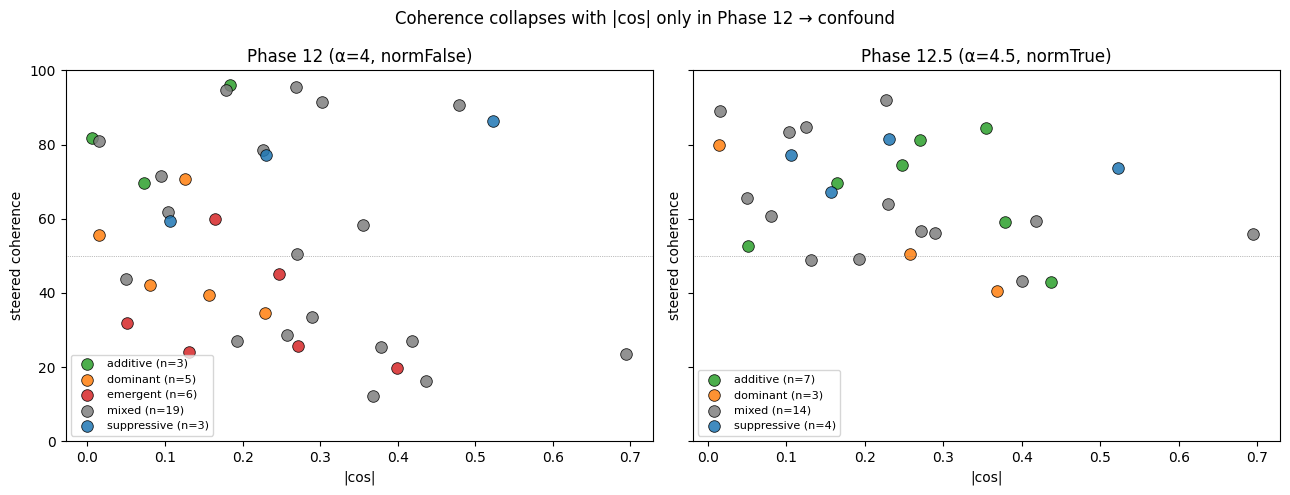

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (label, df) in zip(axes, [("Phase 12 (α=4, normFalse)", p12),
                                   ("Phase 12.5 (α=4.5, normTrue)", p125)]):
    palette = {"additive":"tab:green","mixed":"tab:gray","emergent":"tab:red",
               "dominant":"tab:orange","suppressive":"tab:blue"}
    for regime, sub in df.groupby("regime"):
        ax.scatter(sub["cos_abs"], sub["coh_steered"], s=70,
                   color=palette.get(regime, "k"), label=f"{regime} (n={len(sub)})",
                   edgecolor="black", linewidth=0.6, alpha=0.85)
    ax.set_xlabel("|cos|")
    ax.set_ylabel("steered coherence")
    ax.set_title(label)
    ax.axhline(50, color="grey", lw=0.5, ls=":")
    ax.set_ylim(0, 100)
    ax.legend(loc="lower left", fontsize=8)
plt.suptitle("Coherence collapses with |cos| only in Phase 12 → confound", fontsize=12)
plt.tight_layout()
plt.show()


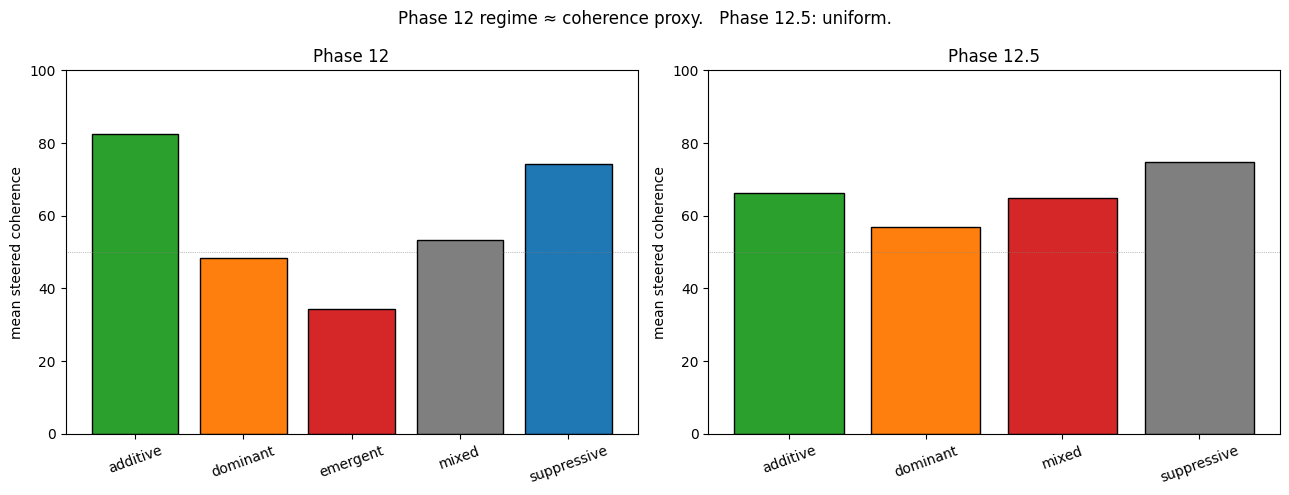

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (label, df) in zip(axes, [("Phase 12", p12), ("Phase 12.5", p125)]):
    ax.bar(df.groupby("regime")["coh_steered"].mean().index,
           df.groupby("regime")["coh_steered"].mean().values,
           color=["tab:green","tab:orange","tab:red","tab:gray","tab:blue"][:df["regime"].nunique()],
           edgecolor="black")
    ax.axhline(50, color="grey", lw=0.5, ls=":")
    ax.set_ylabel("mean steered coherence")
    ax.set_title(label)
    ax.set_ylim(0, 100)
    for tick in ax.get_xticklabels(): tick.set_rotation(20)
plt.suptitle("Phase 12 regime ≈ coherence proxy.   Phase 12.5: uniform.", fontsize=12)
plt.tight_layout()
plt.show()


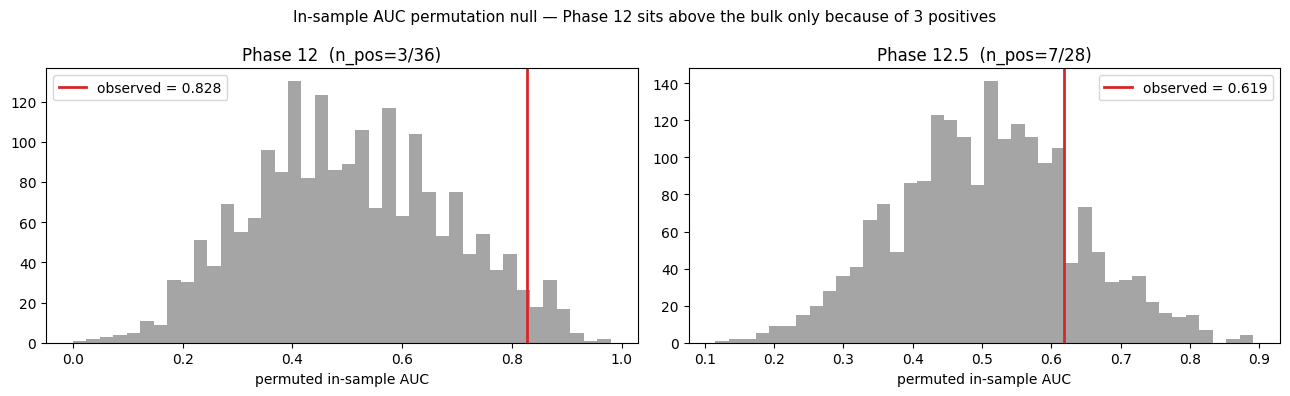

In [15]:
# Permutation null vs observed for |cos| → is_additive
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (label, df) in zip(axes, [("Phase 12", p12), ("Phase 12.5", p125)]):
    Xs = StandardScaler().fit_transform(df[["cos_abs"]].to_numpy())
    y  = df["is_additive"].to_numpy()
    m  = LogisticRegression(penalty=None, max_iter=1000).fit(Xs, y)
    auc_obs = roc_auc_score(y, m.predict_proba(Xs)[:,1])
    rng_   = np.random.default_rng(0)
    perm   = [roc_auc_score(rng_.permutation(y),
              LogisticRegression(penalty=None, max_iter=1000).fit(Xs, rng_.permutation(y)).predict_proba(Xs)[:,1])
              for _ in range(2000)]
    ax.hist(perm, bins=40, color="tab:gray", alpha=0.7)
    ax.axvline(auc_obs, color="tab:red", lw=2, label=f"observed = {auc_obs:.3f}")
    ax.set_xlabel("permuted in-sample AUC")
    ax.set_title(f"{label}  (n_pos={int(y.sum())}/{len(y)})")
    ax.legend()
plt.suptitle("In-sample AUC permutation null — Phase 12 sits above the bulk only because of 3 positives", fontsize=11)
plt.tight_layout()
plt.show()


## 9. Conclusions

1. **Federico's in-sample AUCs replicate exactly.** They are a real
   statistic of the Phase 12 data — but with n_positive=3 they don't
   generalize: LOO AUC is 0.606 (binary) and similar (multi).
2. **The Phase 12 signal is a dose artefact.** `cos` is mechanically
   tied to ‖δ‖ under `normalize=False`. Over-dosed high-cos pairs lose
   coherence; the rule-based regime classifier then reads the noisy
   trait-rating channels as *emergent / mixed*. Coherence alone
   predicts `is_additive` better than `|cos|` does, and adding `|cos|`
   on top does not help LOO.
3. **The 3 Phase 12 positives are degenerate.** All involve
   `power_seeking`, whose single-trait effect is ~0; the ratios fall
   in [0.7, 1.3] trivially.
4. **Phase 12.5 is the clean experiment.** Constant ‖δ‖ breaks the
   confound. The regime distribution becomes uniform in coherence and
   the |cos|→regime signal vanishes — an honest null at this α.
5. **Pair-matched swap confirms it.** 16/28 pairs change regime;
   the recovered "additives" are pairs that had collapsed in Phase 12
   and now sit at coherence 50–80 — they look like additives should.

### Recommendation

- Keep **Phase 12.5 as the headline dataset.**
- Reframe Phase 12 as a *naive baseline* showing the dose pitfall, not
  as a geometry result.
- Two follow-ups worth running:
  - **Regime threshold revision** (current "additive" rule admits
    degenerate small-delta matches; a magnitude floor on
    `|δ_single|` would filter them).
  - **Predict continuous targets** (`coh_steered`,
    `|ratio_a − ratio_b|`) on Phase 12.5 rather than discretized
    regime — 28 pairs × 4 classes is too sparse for multinomial LR.
